# Técnicas Clásicas de Visión
| IA 5.2 Computer Vision   
| FCEIA - UNR

En este cuaderno se desarrollan ejercicios relacionados a la clase 2 "Técnicas clásicas de Visión" de la materia.

# Librerías a utilizar

In [88]:
# !pip install opencv-python

In [89]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

## Ejercicio 1: Detección de bordes

La detección de bordes es una herramienta fundamental que usan internamente los modelos para poder obtener features de las imágenes / objetos a clasificar / detectar.

## Filtro sobel



> "El operador Sobel es un ejemplo clásico de un detector de características basado en la convolución. No utiliza un solo filtro, sino un par de kernels de 3×3 diseñados para trabajar en conjunto. Su propósito es calcular una aproximación del gradiente de intensidad de la imagen en cada punto. En términos sencillos, miden la tasa y la dirección del cambio de brillo. Un filtro está optimizado para detectar cambios en la dirección horizontal, mientras que el otro lo está para la dirección vertical. Juntos, proporcionan una imagen completa de la estructura de bordes de la escena." -https://datasciencepythonblog.net/los-2-filtros-de-convolucion-del-operador-sobel-tensorflow/



Kernel para resaltado Horizontal ------|-------     Kernel para resaltado Vertical
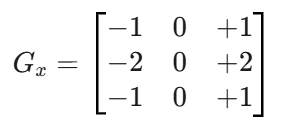 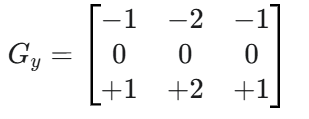

**OJO**
Resaltado horizontal significa que detecta el cambios fuertes de manera horizontal -> resalta lineas verticales.

-->|-->

-->|-->

-->|-->

Resaltado vertical significa que detecta los cambios fuertes de manera vertical -> resalta lineas horizontales

↓ - -  ↓- -   ↓

➖➖➖

↓ - -  ↓- -   ↓


Definición de kernels en python

In [90]:
Gx = np.array([-1,0,1,
      -2,0,2,
      -1,0,1], dtype=np.float32)
Gy = np.array([-1,-2,-1,
       0,0,0,
       1,2,1], dtype=np.float32)

### Ejemplo implementación sobel

Trabajaremos con la siguiente imagen

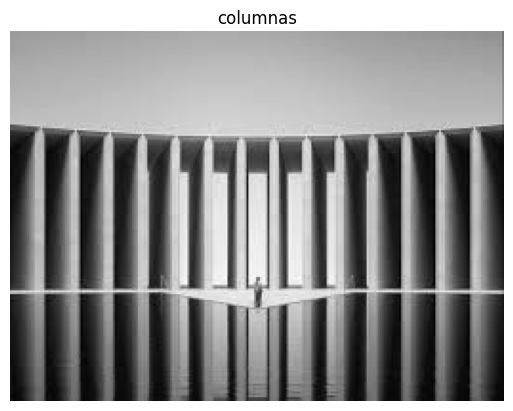

In [91]:
img_columnas_path = './data/columnas.jpg'
columnas = cv2.imread(img_columnas_path)
columnas_gray = cv2.cvtColor(columnas, cv2.COLOR_BGR2GRAY)
plt.figure()
plt.imshow(columnas_gray, cmap='gray')
plt.title('columnas')
plt.axis('off')
plt.show()


### Filtro Horizontal Gx

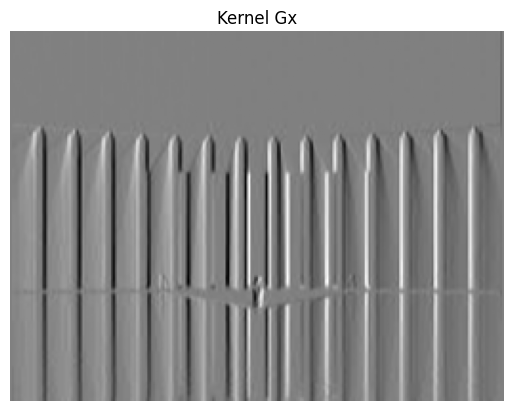

In [92]:
# Aplicamos kernel Gx a imagen para obtener el gradiente horizontal
img_Gx = cv2.filter2D(columnas_gray, cv2.CV_32F, Gx.reshape(3,3))
plt.figure()
plt.imshow(img_Gx, cmap='gray')
plt.title('Kernel Gx')
plt.axis('off')
plt.show()


### Filtro vertical Gy

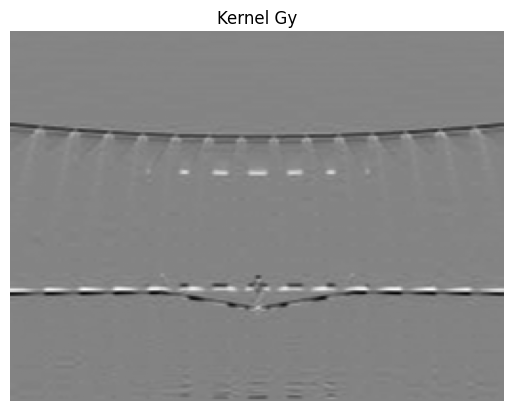

In [93]:
# Aplicamos kernel Gy a imagen para obtener el gradiente vertical
img_Gy = cv2.filter2D(columnas_gray, cv2.CV_32F, Gy.reshape(3,3))
plt.figure()
plt.imshow(img_Gy, cmap='gray')
plt.title('Kernel Gy')
plt.axis('off')
plt.show()

### Calculo de magnitud del gradiente

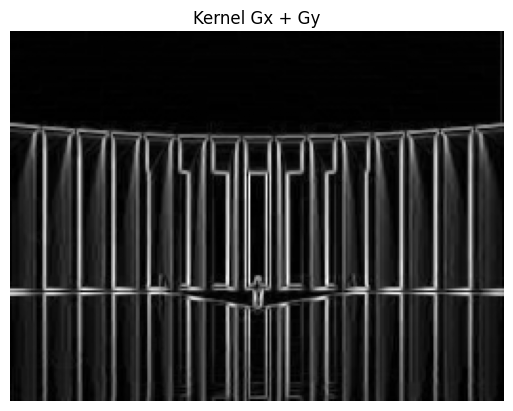

In [94]:
img_columnas_Gx_ = img_Gx.astype(np.float32)
img_columnas_Gy_ = img_Gy.astype(np.float32)

magnitude = np.sqrt(img_columnas_Gx_**2 + img_columnas_Gy_**2)
plt.figure()
plt.imshow(magnitude, cmap='gray')
plt.title('Kernel Gx + Gy')
plt.axis('off')
plt.show()


Falta normalizar

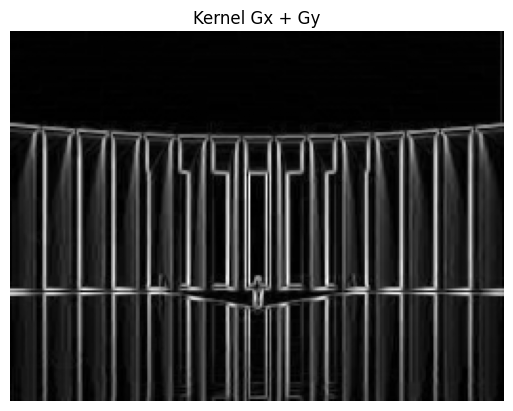

In [95]:
magnitude = cv2.normalize(magnitude, None, 0, 255, cv2.NORM_MINMAX)
magnitude = magnitude.astype(np.uint8)

plt.figure()
plt.imshow(magnitude, cmap='gray')
plt.title('Kernel Gx + Gy')
plt.axis('off')
plt.show()




### Aplicación directa con cv2.sobel

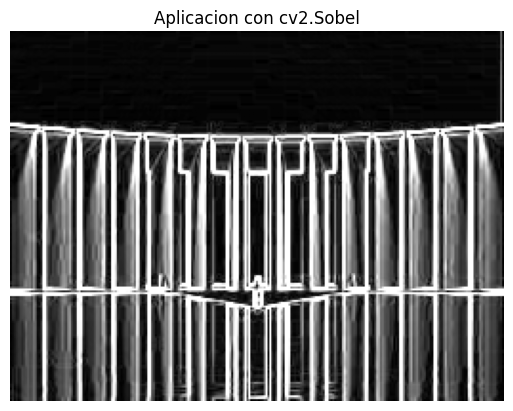

In [96]:
sobel_x = cv2.Sobel(columnas_gray, cv2.CV_32F, 1, 0)
sobel_y = cv2.Sobel(columnas_gray, cv2.CV_32F, 0, 1)

magnitude = cv2.magnitude(sobel_x, sobel_y)
magnitude = cv2.convertScaleAbs(magnitude)

plt.figure()
plt.imshow(magnitude, cmap='gray')
plt.title('Aplicacion con cv2.Sobel')
plt.axis('off')
plt.show()



## Canny

>"El algoritmo de Canny es usado para detectar todos los bordes existentes en una imagen. Este algoritmo esta considerado como uno de los mejores métodos de detección de contornos mediante el empleo de máscaras de convolución y basado en la primera derivada. Los puntos de contorno son como zonas de píxels en las que existe un cambio brusco de nivel de gris." 

Jorge Valverde Rebaza - "Detección de bordes mediante el algoritmo de Canny", 2014. [Link](https://www.cs.buap.mx/~daniel.valdes/docs/Deteccion_de_bordes_mediante_el_algoritmo_de_Canny.pdf)

El algoritmo de Canny consiste en tres grandes pasos:

• **Obtención del gradiente:** en este paso se calcula la magnitud y orientación del vector gradiente en cada píxel.

• **Supresión no máxima:** en este paso se logra el adelgazamiento del ancho de los bordes, obtenidos con el gradiente, hasta lograr bordes de un píxel de ancho.

• **Histéresis de umbral:** en este paso se aplica una función de histéresis basada en dos umbrales; con este proceso se pretende reducir la posibilidad de aparición de contornos falsos.

Jorge Valverde Rebaza - "Detección de bordes mediante el algoritmo de Canny", 2014. [Link](https://www.cs.buap.mx/~daniel.valdes/docs/Deteccion_de_bordes_mediante_el_algoritmo_de_Canny.pdf)

### Obtención del gradiente

Para la obtención del gradiente, como paso previo, se aplica un filtro gaussiano para suavizar la imagen original y evitar que el posible ruido cree bordes falsos en pasos siguientes.

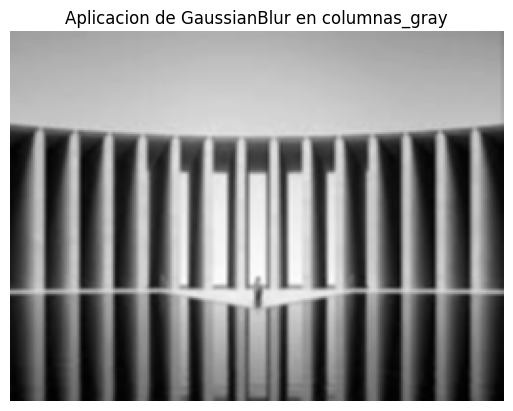

In [97]:
gauss_columnas_gray = cv2.GaussianBlur(columnas_gray, (3,3),1)
plt.figure()
plt.imshow(gauss_columnas_gray, cmap='gray')
plt.title('Aplicacion de GaussianBlur en columnas_gray')
plt.axis('off')
plt.show()

Luego, para cada píxel, se obtiene la magnitud y la orientación del gradiente, obteniendo dos imágenes.

- La **magnitud** indica la intensidad del cambio (qué tan fuerte es el borde).
- La **orientación** indica la dirección del cambio (perpendicular al borde). Se calcula con `arctan2(Gy, Gx)` y se visualiza con un colormap HSV donde cada color representa una dirección diferente (0°=rojo, 90°=verde, 180°=azul).

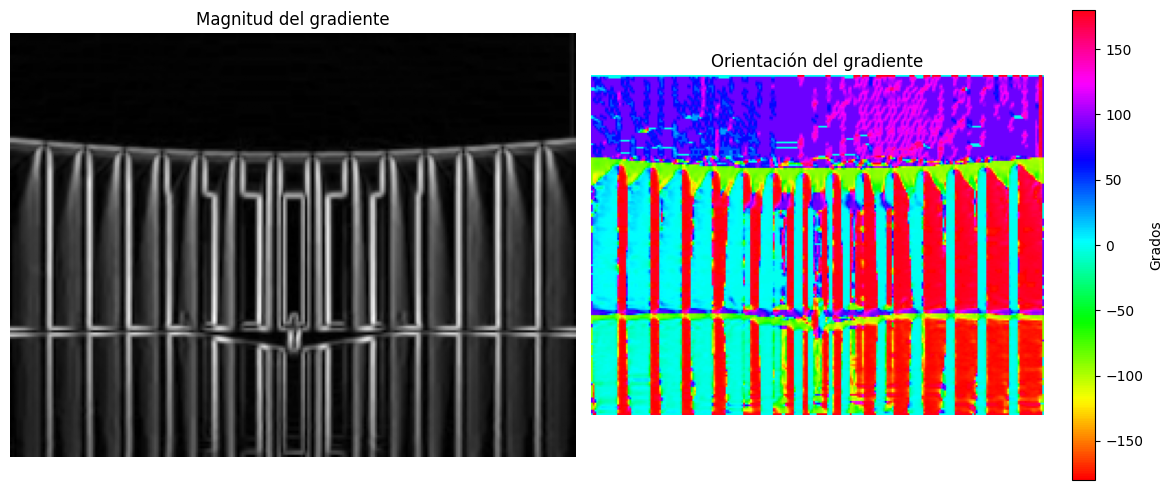

In [98]:
# Calculamos magnitud y orientación del gradiente usando Sobel
sobel_x = cv2.Sobel(gauss_columnas_gray, cv2.CV_32F, 1, 0, ksize=3)
sobel_y = cv2.Sobel(gauss_columnas_gray, cv2.CV_32F, 0, 1, ksize=3)

magnitud = cv2.magnitude(sobel_x, sobel_y)
orientacion = np.arctan2(sobel_y, sobel_x) * (180 / np.pi)  # Convertimos a grados

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(magnitud, cmap='gray')
axes[0].set_title('Magnitud del gradiente')
axes[0].axis('off')

im = axes[1].imshow(orientacion, cmap='hsv')
axes[1].set_title('Orientación del gradiente')
axes[1].axis('off')
plt.colorbar(im, ax=axes[1], label='Grados')

plt.tight_layout()
plt.show()

### Supresión no máxima e histéresis de umbral con `cv2.Canny()`

Los pasos 2 y 3 del algoritmo (supresión no máxima e histéresis de umbral) ya están implementados dentro de `cv2.Canny()`. Solo necesitamos definir los **dos umbrales** de la histéresis:
- `threshold1` (umbral bajo): bordes con gradiente menor a este valor se descartan.
- `threshold2` (umbral alto): bordes con gradiente mayor a este valor se aceptan directamente.
- Los bordes entre ambos umbrales se aceptan solo si están conectados a un borde fuerte.

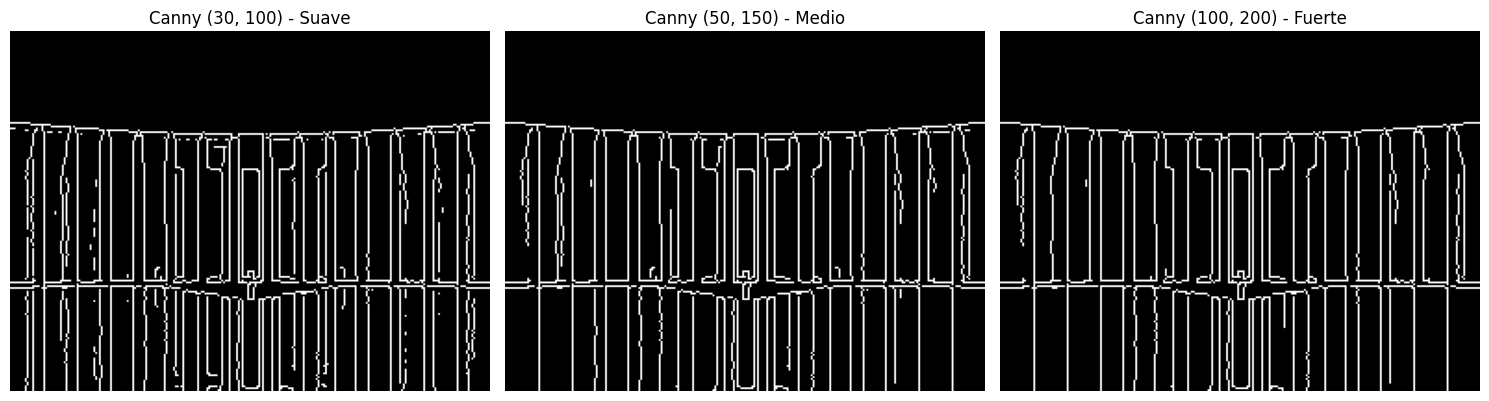

In [99]:
# Aplicamos cv2.Canny con distintos umbrales
canny_suave = cv2.Canny(gauss_columnas_gray, 30, 100)    # Umbrales bajos: detecta mas bordes
canny_medio = cv2.Canny(gauss_columnas_gray, 50, 150)    # Umbrales medios
canny_fuerte = cv2.Canny(gauss_columnas_gray, 100, 200)  # Umbrales altos: solo bordes fuertes

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(canny_suave, cmap='gray')
axes[0].set_title('Canny (30, 100) - Suave')
axes[0].axis('off')

axes[1].imshow(canny_medio, cmap='gray')
axes[1].set_title('Canny (50, 150) - Medio')
axes[1].axis('off')

axes[2].imshow(canny_fuerte, cmap='gray')
axes[2].set_title('Canny (100, 200) - Fuerte')
axes[2].axis('off')

plt.tight_layout()
plt.show()

**Observacion:** A medida que aumentamos los umbrales, se eliminan bordes debiles y solo quedan los mas prominentes. La eleccion de umbrales depende de la aplicacion y del nivel de detalle deseado.

### Comparacion directa: Sobel vs Canny

Sobel produce una imagen de **magnitud continua** (cada píxel tiene un valor proporcional a la intensidad del borde), mientras que Canny produce una imagen **binaria** (cada píxel es borde o no). Canny además produce bordes de **1 píxel de ancho** gracias a la supresión no máxima.

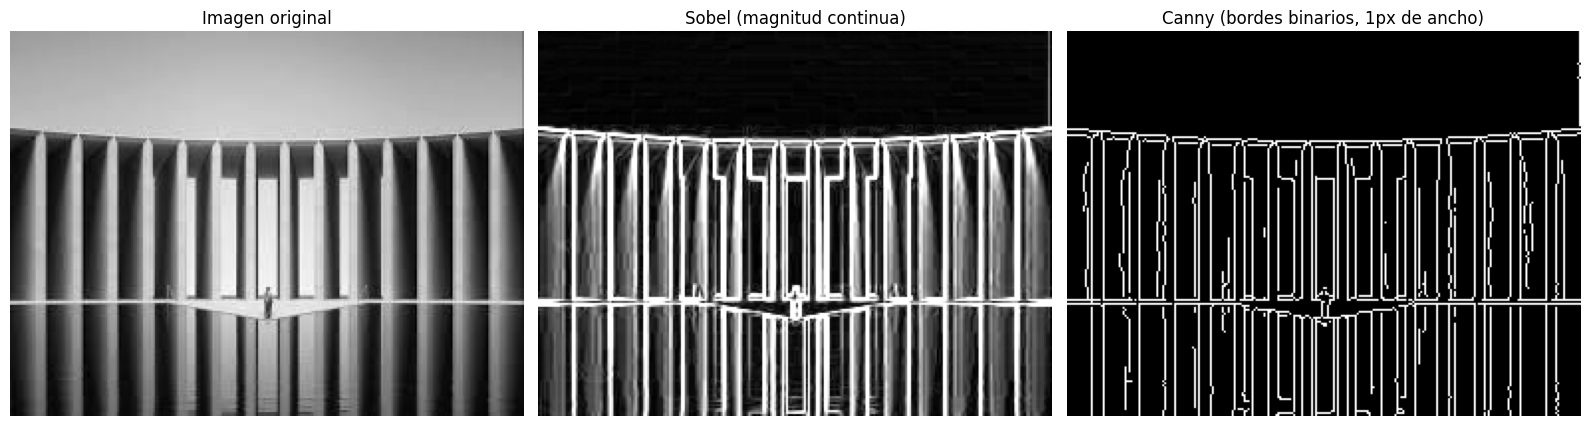

Sobel: 24249 pixeles con magnitud > 50
Canny: 6342 pixeles de borde


In [100]:
# Comparacion Sobel vs Canny sobre la misma imagen
sobel_comp = cv2.magnitude(
    cv2.Sobel(columnas_gray, cv2.CV_32F, 1, 0),
    cv2.Sobel(columnas_gray, cv2.CV_32F, 0, 1)
)
sobel_comp = cv2.convertScaleAbs(sobel_comp)
canny_comp = cv2.Canny(columnas_gray, 50, 150)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].imshow(columnas_gray, cmap='gray')
axes[0].set_title('Imagen original')
axes[0].axis('off')

axes[1].imshow(sobel_comp, cmap='gray')
axes[1].set_title('Sobel (magnitud continua)')
axes[1].axis('off')

axes[2].imshow(canny_comp, cmap='gray')
axes[2].set_title('Canny (bordes binarios, 1px de ancho)')
axes[2].axis('off')

plt.tight_layout()
plt.show()

# Contamos pixeles de borde para comparar
print(f'Sobel: {np.sum(sobel_comp > 50)} pixeles con magnitud > 50')
print(f'Canny: {np.sum(canny_comp > 0)} pixeles de borde')

# Consigna Sobel / Canny

Remarca los ladrillos en la siguiente foto "ladrillos.jpg".

Luego cuenta la cantidad de ladrillos (de manera aproximada, no es necesario que de exacto).

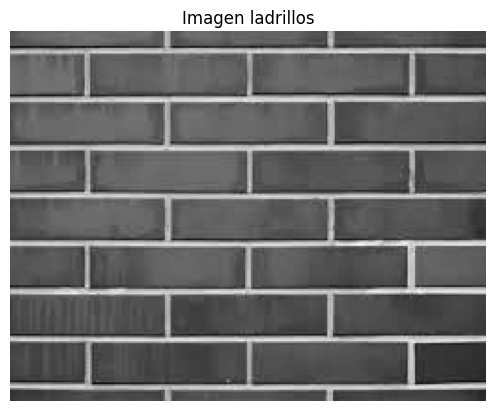

In [101]:
ladrillos = cv2.imread('./data/ladrillos.jpg')
ladrillos_gray = cv2.cvtColor(ladrillos, cv2.COLOR_BGR2GRAY)
plt.figure()
plt.imshow(ladrillos_gray, cmap='gray')
plt.title('Imagen ladrillos')
plt.axis('off')
plt.show()

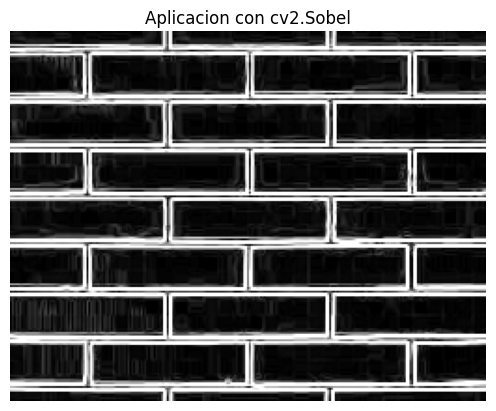

In [102]:
sobel_x = cv2.Sobel(ladrillos_gray, cv2.CV_32F, 1, 0)
sobel_y = cv2.Sobel(ladrillos_gray, cv2.CV_32F, 0, 1)

magnitude_ladrillos = cv2.magnitude(sobel_x, sobel_y)
magnitude_ladrillos = cv2.convertScaleAbs(magnitude_ladrillos)

plt.figure()
plt.imshow(magnitude_ladrillos, cmap='gray')
plt.title('Aplicacion con cv2.Sobel')
plt.axis('off')
plt.show()

## Posible solucion 

In [103]:
# Normalizar a 8 bits
sobel_x = cv2.convertScaleAbs(sobel_x)
sobel_y = cv2.convertScaleAbs(sobel_y)

# Umbral binario
_, bin_x = cv2.threshold(sobel_x, 160, 255, cv2.THRESH_BINARY)
_, bin_y = cv2.threshold(sobel_y, 160, 255, cv2.THRESH_BINARY)

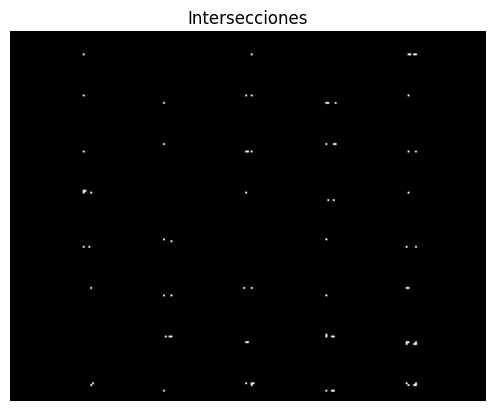

In [104]:
intersecciones = cv2.bitwise_and(bin_x, bin_y)

plt.imshow(intersecciones, cmap='gray')
plt.title("Intersecciones")
plt.axis('off')
plt.show()

In [105]:
num_labels, labels = cv2.connectedComponents(intersecciones)

# Restamos 1 porque el fondo cuenta como etiqueta
num_intersecciones = num_labels - 1

print("Número de intersecciones:", num_intersecciones)

Número de intersecciones: 54


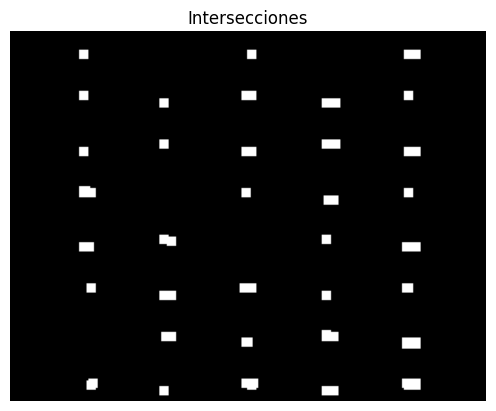

In [106]:
kernel = np.ones((5,5), np.uint8)
intersecciones_close = cv2.morphologyEx(intersecciones, cv2.MORPH_DILATE, kernel)

plt.imshow(intersecciones_close, cmap='gray')
plt.title("Intersecciones")
plt.axis('off')
plt.show()


In [107]:
num_labels_close, labels = cv2.connectedComponents(intersecciones_close)

# Restamos 1 porque el fondo cuenta como etiqueta
num_intersecciones_close = num_labels_close - 1

print("Número de intersecciones:", num_intersecciones_close)

Número de intersecciones: 35


# Ejercicios Canny

## Ejercicio 2: Canny sobre ladrillos

Aplicar `cv2.Canny()` a la imagen `ladrillos.jpg` con al menos 3 combinaciones de umbrales diferentes.

**Pasos concretos:**
1. Convertir `ladrillos_gray` a formato adecuado (ya está en uint8, listo para Canny).
2. Probar al menos estas 3 combinaciones: `(30, 80)`, `(50, 150)`, `(100, 200)`.
3. Mostrar los 3 resultados en un subplot de `1x3` con `figsize=(15, 5)`.
4. En un segundo subplot de `1x2`, comparar el **mejor resultado de Canny** vs el **resultado de Sobel** (magnitud) del ejercicio anterior.

**Preguntas a responder en una celda markdown:**
1. Con qué umbrales se obtiene el mejor resultado para resaltar los bordes de los ladrillos?
2. Qué diferencias observan entre Sobel y Canny para esta imagen? (grosor de bordes, cantidad de ruido, continuidad de los contornos)

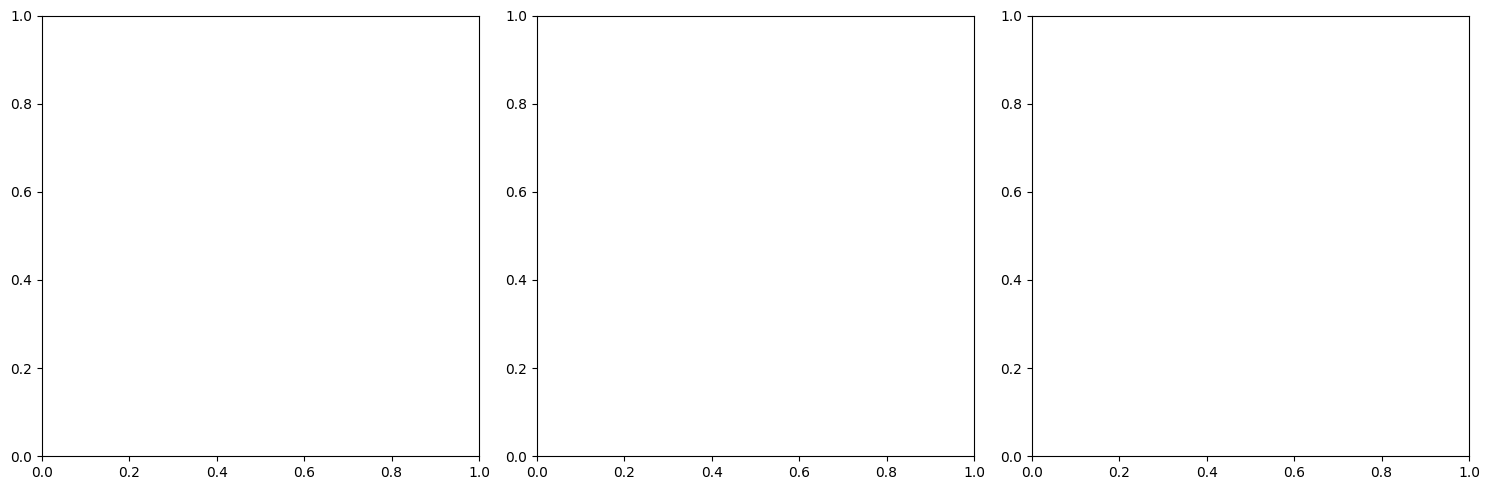

In [108]:
# Ejercicio 2: Completar aqui

# Paso 1-3: Probar distintos umbrales
umbrales = [(30, 80), (50, 150), (100, 200)]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, (t1, t2) in enumerate(umbrales):
    # TODO: aplicar cv2.Canny con los umbrales t1, t2
    # canny_result = ...
    # axes[i].imshow(...)
    # axes[i].set_title(f'Canny ({t1}, {t2})')
    # axes[i].axis('off')
    pass
plt.tight_layout()
plt.show()

# Paso 4: Comparar mejor Canny vs Sobel
# fig, axes = plt.subplots(1, 2, figsize=(12, 5))
# TODO: mostrar lado a lado el mejor Canny y el Sobel de ladrillos


### Solución Ejercicio 2

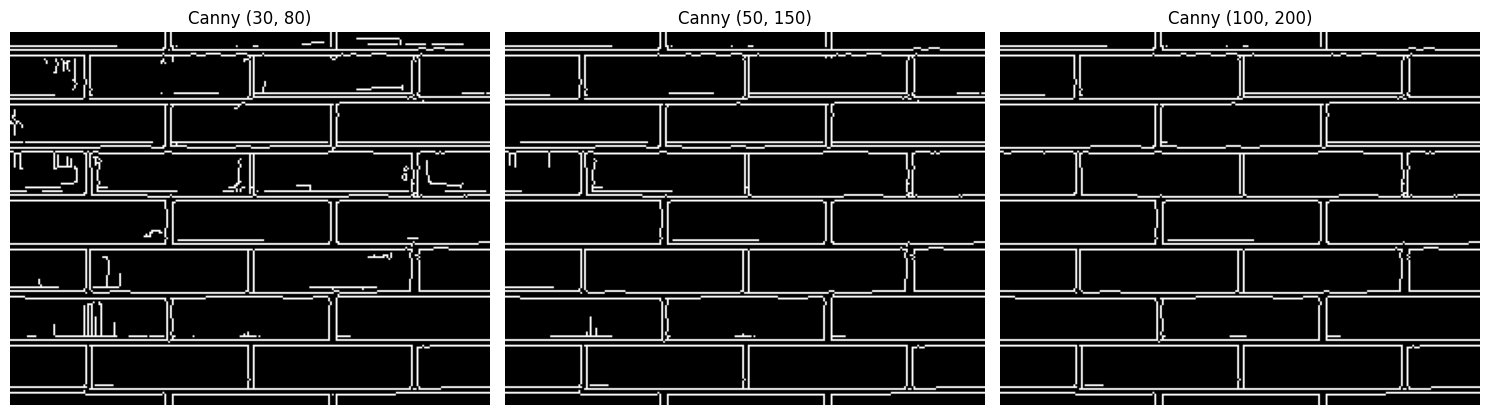

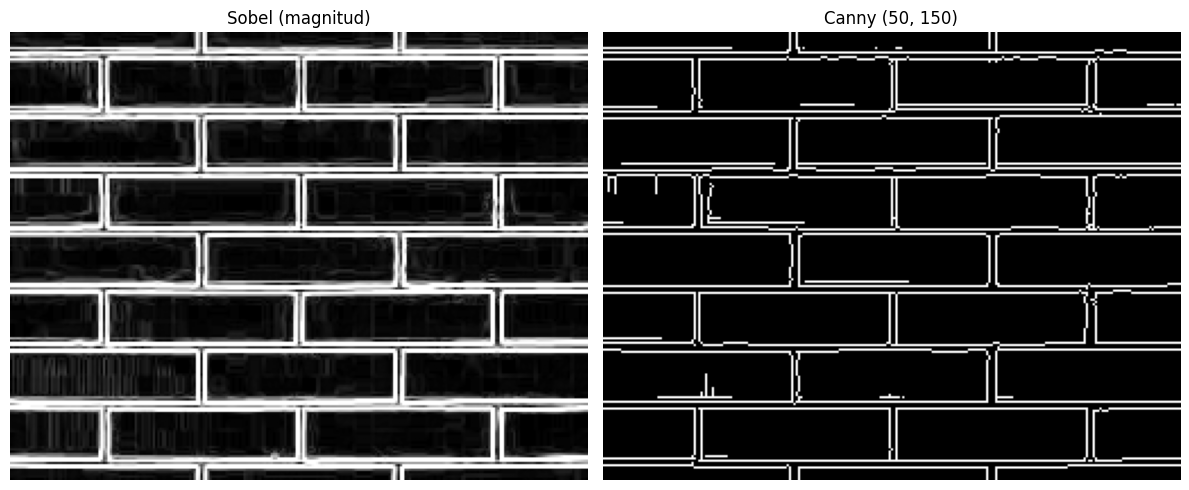

Canny (30, 80): 6245 px de borde
Canny (50, 150): 5537 px de borde
Canny (100, 200): 5172 px de borde
Sobel (magnitud > 50): 15884 px de borde


In [109]:
# Solucion Ejercicio 2

umbrales = [(30, 80), (50, 150), (100, 200)]
resultados_canny = {}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, (t1, t2) in enumerate(umbrales):
    canny_result = cv2.Canny(ladrillos_gray, t1, t2)
    resultados_canny[(t1, t2)] = canny_result
    axes[i].imshow(canny_result, cmap='gray')
    axes[i].set_title(f'Canny ({t1}, {t2})')
    axes[i].axis('off')
plt.tight_layout()
plt.show()

# Comparamos el mejor Canny vs Sobel
mejor_canny = resultados_canny[(50, 150)]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(magnitude_ladrillos, cmap='gray')
axes[0].set_title('Sobel (magnitud)')
axes[0].axis('off')
axes[1].imshow(mejor_canny, cmap='gray')
axes[1].set_title('Canny (50, 150)')
axes[1].axis('off')
plt.tight_layout()
plt.show()

# Conteo de pixeles de borde
for (t1, t2), resultado in resultados_canny.items():
    print(f'Canny ({t1}, {t2}): {np.sum(resultado > 0)} px de borde')
print(f'Sobel (magnitud > 50): {np.sum(magnitude_ladrillos > 50)} px de borde')

## Ejercicio 3: Robustez al ruido - Sobel vs Canny

En este ejercicio vamos a agregar ruido gaussiano a una imagen y comparar como se comportan Sobel y Canny.

**Pasos concretos:**
1. Usar la funcion `agregar_ruido_gaussiano()` proporcionada abajo para generar `img_ruidosa` con `sigma=25`.
2. Calcular la magnitud de Sobel sobre `columnas_gray` (original) y sobre `img_ruidosa`.
3. Calcular Canny con umbrales `(50, 150)` sobre `columnas_gray` y sobre `img_ruidosa`.
4. Mostrar los 4 resultados en un subplot de `2x2`:
   - Fila superior: Sobel original | Sobel ruidoso
   - Fila inferior: Canny original | Canny ruidoso
5. Contar la cantidad de pixeles de borde en cada caso con `np.sum(imagen > umbral)`.

**Preguntas a responder:**
1. Cual de los dos metodos es mas robusto al ruido? Por que?
2. Que pasa si aplicamos `GaussianBlur` a la imagen ruidosa antes de Sobel? Mejora?

**Pista:** Canny aplica internamente un suavizado gaussiano, lo que le da ventaja frente al ruido.

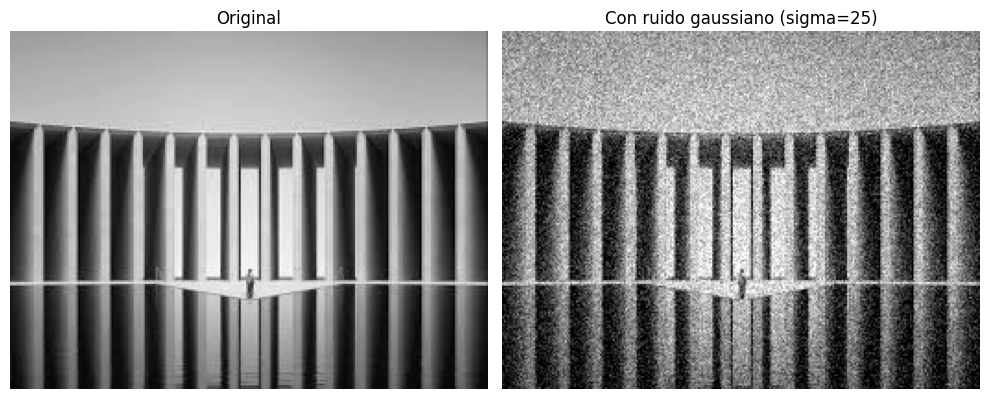

In [110]:
def agregar_ruido_gaussiano(imagen, sigma=25):
    """Agrega ruido gaussiano a una imagen en escala de grises."""
    ruido = np.random.normal(0, sigma, imagen.shape).astype(np.float32)
    imagen_ruidosa = np.clip(imagen.astype(np.float32) + ruido, 0, 255).astype(np.uint8)
    return imagen_ruidosa

# Ejemplo de uso
img_ruidosa = agregar_ruido_gaussiano(columnas_gray, sigma=25)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(columnas_gray, cmap='gray')
axes[0].set_title('Original')
axes[0].axis('off')
axes[1].imshow(img_ruidosa, cmap='gray')
axes[1].set_title('Con ruido gaussiano (sigma=25)')
axes[1].axis('off')
plt.tight_layout()
plt.show()

In [111]:
# Ejercicio 3: Completar aqui

# Paso 2: Sobel sobre original y ruidosa
# sobel_orig = cv2.convertScaleAbs(cv2.magnitude(
#     cv2.Sobel(columnas_gray, cv2.CV_32F, 1, 0),
#     cv2.Sobel(columnas_gray, cv2.CV_32F, 0, 1)))
# sobel_ruido = ... (idem con img_ruidosa)

# Paso 3: Canny sobre original y ruidosa
# canny_orig = cv2.Canny(columnas_gray, 50, 150)
# canny_ruido = ... (idem con img_ruidosa)

# Paso 4: Visualizar en grid 2x2
# fig, axes = plt.subplots(2, 2, figsize=(12, 10))
# axes[0, 0].imshow(sobel_orig, cmap='gray')
# axes[0, 0].set_title('Sobel - Original')
# TODO: completar los otros 3 subplots

# Paso 5: Contar pixeles de borde
# print(f'Sobel original: {np.sum(sobel_orig > 50)} pixeles')
# print(f'Sobel ruidoso: {np.sum(sobel_ruido > 50)} pixeles')
# print(f'Canny original: {np.sum(canny_orig > 0)} pixeles')
# print(f'Canny ruidoso: {np.sum(canny_ruido > 0)} pixeles')


### Solución Ejercicio 3

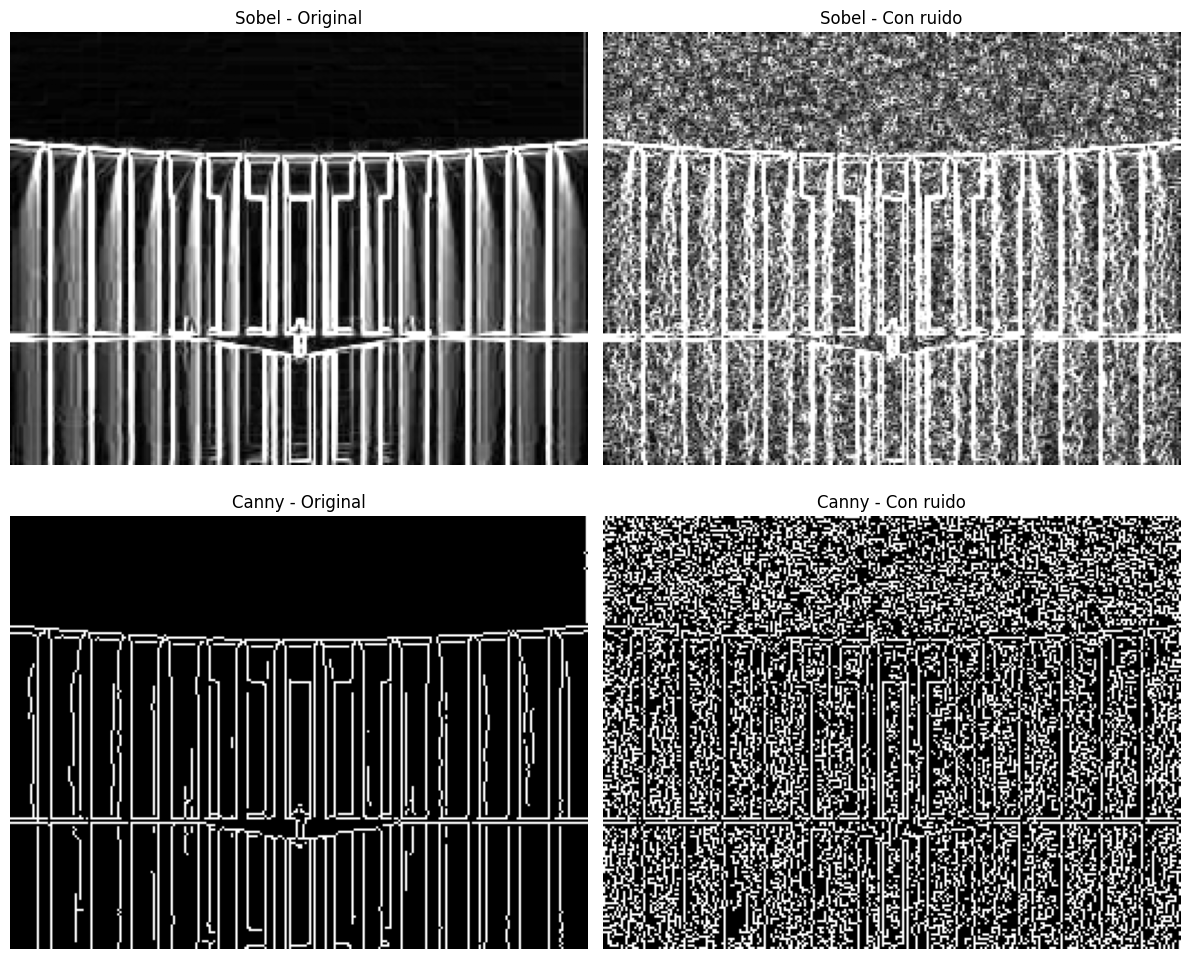

Sobel original: 24249 px
Sobel ruidoso:  44312 px
Canny original: 6342 px
Canny ruidoso:  17447 px
Sobel ruidoso + GaussianBlur previo: 31451 px


In [112]:
# Solucion Ejercicio 3

img_ruidosa = agregar_ruido_gaussiano(columnas_gray, sigma=25)

# Sobel sobre original y ruidosa
sobel_orig = cv2.convertScaleAbs(cv2.magnitude(
    cv2.Sobel(columnas_gray, cv2.CV_32F, 1, 0),
    cv2.Sobel(columnas_gray, cv2.CV_32F, 0, 1)))
sobel_ruido = cv2.convertScaleAbs(cv2.magnitude(
    cv2.Sobel(img_ruidosa, cv2.CV_32F, 1, 0),
    cv2.Sobel(img_ruidosa, cv2.CV_32F, 0, 1)))

# Canny sobre original y ruidosa
canny_orig = cv2.Canny(columnas_gray, 50, 150)
canny_ruido = cv2.Canny(img_ruidosa, 50, 150)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes[0, 0].imshow(sobel_orig, cmap='gray')
axes[0, 0].set_title('Sobel - Original')
axes[0, 0].axis('off')
axes[0, 1].imshow(sobel_ruido, cmap='gray')
axes[0, 1].set_title('Sobel - Con ruido')
axes[0, 1].axis('off')
axes[1, 0].imshow(canny_orig, cmap='gray')
axes[1, 0].set_title('Canny - Original')
axes[1, 0].axis('off')
axes[1, 1].imshow(canny_ruido, cmap='gray')
axes[1, 1].set_title('Canny - Con ruido')
axes[1, 1].axis('off')
plt.tight_layout()
plt.show()

# Comparacion cuantitativa
print(f'Sobel original: {np.sum(sobel_orig > 50)} px')
print(f'Sobel ruidoso:  {np.sum(sobel_ruido > 50)} px')
print(f'Canny original: {np.sum(canny_orig > 0)} px')
print(f'Canny ruidoso:  {np.sum(canny_ruido > 0)} px')

# Bonus: que pasa si suavizamos antes de Sobel?
img_ruidosa_suavizada = cv2.GaussianBlur(img_ruidosa, (5, 5), 1)
sobel_ruido_suav = cv2.convertScaleAbs(cv2.magnitude(
    cv2.Sobel(img_ruidosa_suavizada, cv2.CV_32F, 1, 0),
    cv2.Sobel(img_ruidosa_suavizada, cv2.CV_32F, 0, 1)))
print(f'Sobel ruidoso + GaussianBlur previo: {np.sum(sobel_ruido_suav > 50)} px')